In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from fredapi import Fred

os.environ["FRED_API_KEY"] = "11655f710ab00c681b87ea3dc126ea87"
fred = Fred(api_key=os.environ["FRED_API_KEY"])

In [3]:
recession = fred.get_series(
    "USREC",
    observation_start="1963-01-01",
    observation_end="2024-12-31"
)

# Clean the data
recession_df = recession.rename("USREC").to_frame()
recession_df.index.name = "date"
recession_df["USREC"] = recession_df["USREC"].astype("Int64")

print(recession_df.head())
print(recession_df.tail())

            USREC
date             
1963-01-01      0
1963-02-01      0
1963-03-01      0
1963-04-01      0
1963-05-01      0
            USREC
date             
2024-08-01      0
2024-09-01      0
2024-10-01      0
2024-11-01      0
2024-12-01      0


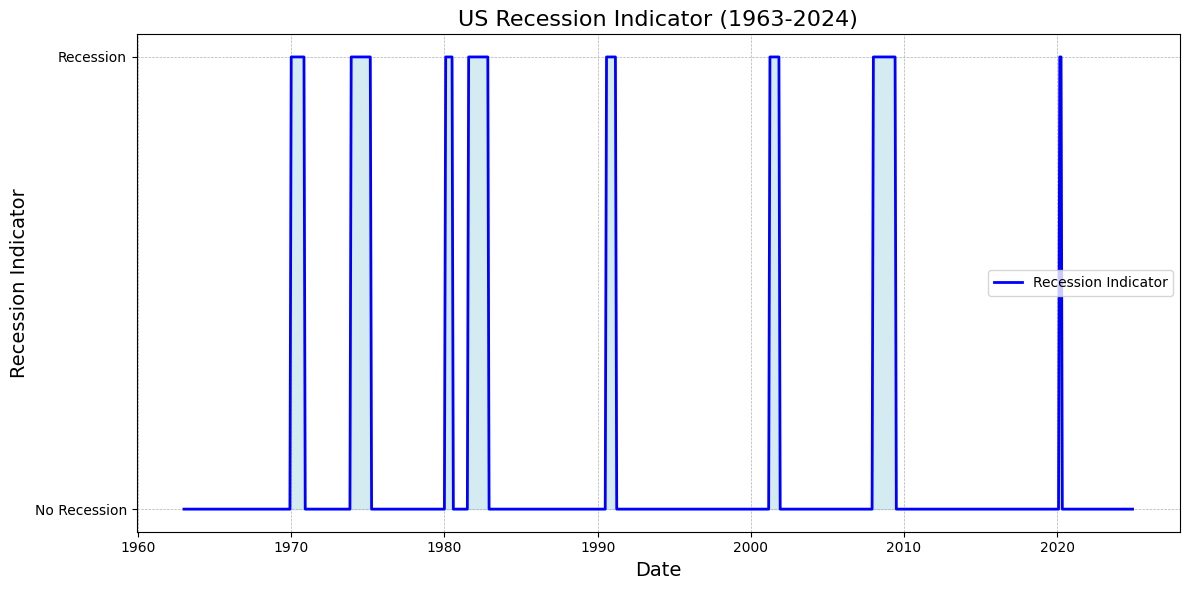

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(recession_df.index, recession_df["USREC"], label="Recession Indicator",
            color="blue", linewidth=2)
plt.fill_between(recession_df.index, recession_df["USREC"], color="lightblue", alpha=0.5)
plt.title("US Recession Indicator (1963-2024)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Recession Indicator", fontsize=14)
plt.yticks([0, 1], ["No Recession", "Recession"])
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()